In [1]:
!pip install boto3 mlflow==3.11.1

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 49.2/49.2 kB 3.7 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 50.0/50.0 kB 5.7 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 43.5/43.5 kB 3.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 10.5/10.5 MB 69.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 3.2/3.2 MB 52.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.6/1.6 MB 57.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 140.5/140.5 kB 13.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 15.2/15.2 MB 86.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 4.5/4.5 MB 90.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 147.8/147.8 kB 17.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 114.9/114.9 kB 14.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 208.4/208.4 kB 24.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 77.

In [2]:
import torch
import torch.nn as nn
from torch.utils.data import Dataset, DataLoader
from torch.optim.lr_scheduler import StepLR
from tqdm import tqdm

import json
import os

from bert_pytorch.dataset import load_vocab, load_log_data, LogBERTDataset
from bert_pytorch.model import build_transformer
from bert_pytorch.predictor import Predictor

from sklearn.metrics import f1_score

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

import mlflow
import mlflow.transformers
from mlflow.tracking import MlflowClient

In [ ]:
os.environ["MLFLOW_TRACKING_URI"] = os.getenv("MLFLOW_TRACKING_URI", "YOUR_IP_ADDRESS:MLFLOW_PORT")
os.environ["MLFLOW_S3_ENDPOINT_URL"] = "YOUR_IP_ADDRESS:MINIO_PORT"

os.environ["AWS_ACCESS_KEY_ID"] = "YOUR_USERNAME"
os.environ["AWS_SECRET_ACCESS_KEY"] = "YOUR_PASSWORD"

mlflow.set_tracking_uri(os.environ["MLFLOW_TRACKING_URI"])

In [4]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Device: {device}")

Device: cuda


Загружаем словарь токенов, тренировочный, валидационный и тестовый датасеты. В них заранее собраны последовательности шаблонизированных логов с помощью Drain.

In [17]:
vocab = load_vocab("vocab.json")
train_log_sequences = load_log_data("train.csv")
val_normal_log_sequences = load_log_data("validation_normal.csv")
val_abnormal_log_sequences = load_log_data("validation_abnormal.csv")
test_normal_log_sequences = load_log_data("test_normal.csv")
test_abnormal_log_sequences = load_log_data("test_abnormal.csv")

Гиперпараметр маскирования данных. Можно варьировать для получения оптимальных результатов

In [18]:
mask_ratio = 0.65

In [19]:
train_dataset = LogBERTDataset(vocab=vocab, sequences=train_log_sequences, seq_len=512, mask_ratio=mask_ratio)
val_normal_dataset = LogBERTDataset(vocab=vocab, sequences=val_normal_log_sequences, seq_len=512, mask_ratio=mask_ratio)
val_abnormal_dataset = LogBERTDataset(vocab=vocab, sequences=val_abnormal_log_sequences, seq_len=512, mask_ratio=mask_ratio)
test_normal_dataset = LogBERTDataset(vocab=vocab, sequences=test_normal_log_sequences, seq_len=512, mask_ratio=mask_ratio, predict_mode=True)
test_abnormal_dataset = LogBERTDataset(vocab=vocab, sequences=test_abnormal_log_sequences, seq_len=512, mask_ratio=mask_ratio, predict_mode=True)

In [20]:
train_dataloader = DataLoader(train_dataset, batch_size=64, shuffle=True, num_workers=2, collate_fn=train_dataset.collate_fn)
val_normal_dataloader = DataLoader(val_normal_dataset, batch_size=64, shuffle=False, num_workers=2, collate_fn=val_normal_dataset.collate_fn)
val_abnormal_dataloader = DataLoader(val_abnormal_dataset, batch_size=64, shuffle=False, num_workers=2, collate_fn=val_abnormal_dataset.collate_fn)
test_normal_dataloader = DataLoader(test_normal_dataset, batch_size=64, shuffle=False, num_workers=2, collate_fn=test_normal_dataset.collate_fn)
test_abnormal_dataloader = DataLoader(test_abnormal_dataset, batch_size=64, shuffle=False, num_workers=2, collate_fn=test_abnormal_dataset.collate_fn)

Сборка полного трансформера. Из него нам понадобятся только энкодер

In [ ]:
model = build_transformer(len(vocab), len(vocab), 512, 512)

In [ ]:
model = model.to(device)

In [ ]:
def train_epoch(model, dataloader, criterion, optimizer, device, epoch_num, pad_id):
    model.train()

    total_loss = 0.0
    all_preds = []
    all_labels = []
    num_batches = 0

    print(f"\n{'='*60}")
    print(f"\nEpoch {epoch_num} - Training")
    print(f"\n{'='*60}")

    for batch_idx, batch in enumerate(dataloader, 1):
        input_ids = batch["input_ids"].to(device)
        labels = batch["labels"].to(device)
        pad_mask = (input_ids == vocab["PAD"]).to(device)

        optimizer.zero_grad()

        encoded = model.encode(
            src=input_ids,
            src_mask=None,
            src_key_padding_mask=pad_mask
        )

        logits = model.project(encoded)

        loss = criterion(
            logits.view(-1, logits.size(-1)),
            labels.view(-1)
        )

        loss.backward()
        optimizer.step()

        total_loss += loss.item()
        num_batches += 1
        predictions = logits.argmax(dim=-1)
        active_mask = (labels != -100)

        all_preds.extend(predictions[active_mask].cpu().numpy())
        all_labels.extend(labels[active_mask].cpu().numpy())

        if batch_idx % 100 == 0 or batch_idx == len(dataloader):
            print(f"Batch {batch_idx}/{len(dataloader)} | Loss: {loss.item():.4f}")

    avg_loss = total_loss / num_batches

    if len(all_labels) > 0:
        epoch_f1 = f1_score(all_labels, all_preds, average="macro", zero_division=0)
    else:
        epoch_f1 = 0

    print(f"\nEpoch {epoch_num} Summary (Train):")
    print(f"Average Loss: {avg_loss:.4f}")
    print(f"F1 Score: {epoch_f1:.4f}")

    return {"loss": avg_loss, "f1": epoch_f1}

In [ ]:
@torch.no_grad()
def validate_epoch(model, dataloader, criterion, device, epoch_num, pad_id):
    model.eval()

    total_loss = 0

    all_preds = []
    all_labels = []
    num_batches = 0

    print(f"\n{'='*60}")
    print(f"\nEpoch {epoch_num} - Validation")
    print(f"\n{'='*60}")

    for batch in dataloader:
        input_ids = batch["input_ids"].to(device)
        labels = batch["labels"].to(device)
        pad_mask = (input_ids == vocab["PAD"]).to(device)

        encoded = model.encode(
            src=input_ids,
            src_mask=None,
            src_key_padding_mask=pad_mask
        )

        logits = model.project(encoded)

        loss = criterion(
            logits.view(-1, logits.size(-1)),
            labels.view(-1)
        )


        total_loss += loss.item()
        num_batches += 1
        predictions = logits.argmax(dim=-1)
        active_mask = (labels != -100)

        all_preds.extend(predictions[active_mask].cpu().numpy())
        all_labels.extend(labels[active_mask].cpu().numpy())

        if num_batches % 100 == 0 or num_batches == len(dataloader):
            print(f"Batch {num_batches}/{len(dataloader)} | Loss: {loss.item():.4f}")

    avg_loss = total_loss / num_batches

    if len(all_labels) > 0:
        epoch_f1 = f1_score(all_labels, all_preds, average="macro", zero_division=0)
    else:
        epoch_f1 = 0

    print(f"\nEpoch {epoch_num} Summary (Validation):")
    print(f"Average Loss: {avg_loss:.4f}")
    print(f"F1 Score: {epoch_f1:.4f}")

    return {"loss": avg_loss, "f1": epoch_f1}

In [ ]:
def train_model(model, train_dataloader, val_dataloader, optimizer, criterion, scheduler, pad_id, device, num_epochs, save_path, exp_id, run_name, params):
    with mlflow.start_run(experiment_id=exp_id, run_name=run_name) as run:

        print(f"\nStarting training for {num_epochs} epochs")
        print(f"Device: {device}")
        print(f"Train batches: {len(train_dataloader)}, Val batches: {len(val_dataloader)}")

        mlflow.log_params(params)

        history = {
            'train_loss': [],
            'train_f1': [],
            'val_loss': [],
            'val_f1': []
        }

        best_f1_score = 0

        for epoch in range(1, num_epochs + 1):
            train_metrics = train_epoch(
                model, train_dataloader, criterion, optimizer, device, epoch, pad_id
            )
            history['train_loss'].append(train_metrics['loss'])
            history['train_f1'].append(train_metrics['f1'])

            mlflow.log_metrics(
                {
                "train_loss": train_metrics['loss'],
                "train_f1": train_metrics["f1"]
                },
                step=epoch)

            if epoch % 2 == 0:
                val_metrics = validate_epoch(
                    model, val_dataloader, criterion, device, epoch, pad_id
                )
                history['val_loss'].append(val_metrics['loss'])
                history['val_f1'].append(val_metrics['f1'])

                mlflow.log_metrics(
                    {
                        "val_loss": val_metrics['loss'],
                        "val_f1": val_metrics['f1']
                    },
                    step=epoch
                )

                if val_metrics["f1"] > best_f1_score:
                    best_f1_score = val_metrics["f1"]

                    task_components = {
                        "model": model
                    }

                    torch.save({
                        'epoch': epoch,
                        'model_state_dict': model.state_dict(),
                        'optimizer_state_dict': optimizer.state_dict(),
                        "scheduler_state_dict": scheduler.state_dict(),
                        'val_f1': val_metrics['f1'],
                    }, f"{save_path}.pt")

                    print(f"FIND NEW BEST MODEL AT EPOCH {epoch}")

            scheduler.step()

        model_info = mlflow.pytorch.log_model(
            pytorch_model=task_components["model"],
            name="model",
            registered_model_name=registered_model_name,
        )

        new_version = model_info.registered_model_version
        client.set_model_version_tag(registered_model_name, new_version, "env", run_name)
        client.set_registered_model_alias(registered_model_name, run_name, new_version)

    print("Run ID:", run.info.run_id)
    print("Registered model version:", new_version)
    print(f"Alias {run_name} points to version:", new_version)

    return history

In [6]:
num_epochs = 16

In [ ]:
criterion = nn.CrossEntropyLoss(ignore_index=-100)
optimizer = torch.optim.AdamW(model.parameters(), lr=1e-4, weight_decay=0.01)
scheduler = StepLR(optimizer, step_size=4, gamma=0.1)

In [7]:
experiment_name = "logbert"
artifact_location = "mlflow-artifacts:/"
registered_model_name = "logbert"

client = MlflowClient()
exp = mlflow.get_experiment_by_name(experiment_name)
if exp:
    exp_id = exp.experiment_id
else:
    exp_id = client.create_experiment(name=experiment_name, artifact_location=artifact_location)

mlflow.set_experiment(experiment_name)

<Experiment: artifact_location='mlflow-artifacts:/', creation_time=1780962320696, experiment_id='1', last_update_time=1780962320696, lifecycle_stage='active', name='logbert', tags={}, trace_location=None, workspace='default'>

In [8]:
params = {
    "epochs": num_epochs,
    "starting_lr": 1e-4,
    "weight_decay": 0.01,
    "mask_ration": mask_ratio,
    "batch_size": 64,
    "seq_len": 512
}

In [ ]:
history = train_model(model,
                      train_dataloader,
                      val_normal_dataloader,
                      optimizer,
                      criterion,
                      scheduler,
                      vocab["PAD"],
                      device,
                      num_epochs,
                      "log_bert_model",
                      exp_id,
                      f"logbert_05",
                      params)


Starting training for 16 epochs
Device: cuda
Train batches: 6978, Val batches: 873


Epoch 1 - Training

Batch 100/6978 | Loss: 0.6523
Batch 200/6978 | Loss: 0.5121
Batch 300/6978 | Loss: 0.4885
Batch 400/6978 | Loss: 0.3563
Batch 500/6978 | Loss: 0.3185
Batch 600/6978 | Loss: 0.2387
Batch 700/6978 | Loss: 0.2451
Batch 800/6978 | Loss: 0.2937
Batch 900/6978 | Loss: 0.2137
Batch 1000/6978 | Loss: 0.2791
Batch 1100/6978 | Loss: 0.2144
Batch 1200/6978 | Loss: 0.2401
Batch 1300/6978 | Loss: 0.2171
Batch 1400/6978 | Loss: 0.1871
Batch 1500/6978 | Loss: 0.1652
Batch 1600/6978 | Loss: 0.2938
Batch 1700/6978 | Loss: 0.1886
Batch 1800/6978 | Loss: 0.1968
Batch 1900/6978 | Loss: 0.2265
Batch 2000/6978 | Loss: 0.2142
Batch 2100/6978 | Loss: 0.1918
Batch 2200/6978 | Loss: 0.1981
Batch 2300/6978 | Loss: 0.2510
Batch 2400/6978 | Loss: 0.2802
Batch 2500/6978 | Loss: 0.1509
Batch 2600/6978 | Loss: 0.1932
Batch 2700/6978 | Loss: 0.1808
Batch 2800/6978 | Loss: 0.1679
Batch 2900/6978 | Loss: 0.2322
Batc

2026/06/09 03:02:29 WARNING mlflow.pytorch: Saving pytorch model by Pickle or CloudPickle format requires exercising caution because these formats rely on Python's object serialization mechanism, which can execute arbitrary code during deserialization. The recommended safe alternative is to set `serialization_format` to 'pt2' to save the PyTorch model using the safe graph model format.
2026/06/09 03:02:29 WARNING mlflow.utils.requirements_utils: Found torch version (2.11.0+cu128) contains a local version label (+cu128). MLflow logged a pip requirement for this package as 'torch==2.11.0' without the local version label to make it installable from PyPI. To specify pip requirements containing local version labels, please use `conda_env` or `pip_requirements`.
2026/06/09 03:02:35 WARNING mlflow.utils.requirements_utils: Found torch version (2.11.0+cu128) contains a local version label (+cu128). MLflow logged a pip requirement for this package as 'torch==2.11.0' without the local version la

🏃 View run logbert_05 at: http://31.184.199.71:5050/#/experiments/1/runs/cb800f337fad4c06bad07e20502f64b1
🧪 View experiment at: http://31.184.199.71:5050/#/experiments/1
Run ID: cb800f337fad4c06bad07e20502f64b1
Registered model version: 1
Alias logbert_05 points to version: 1


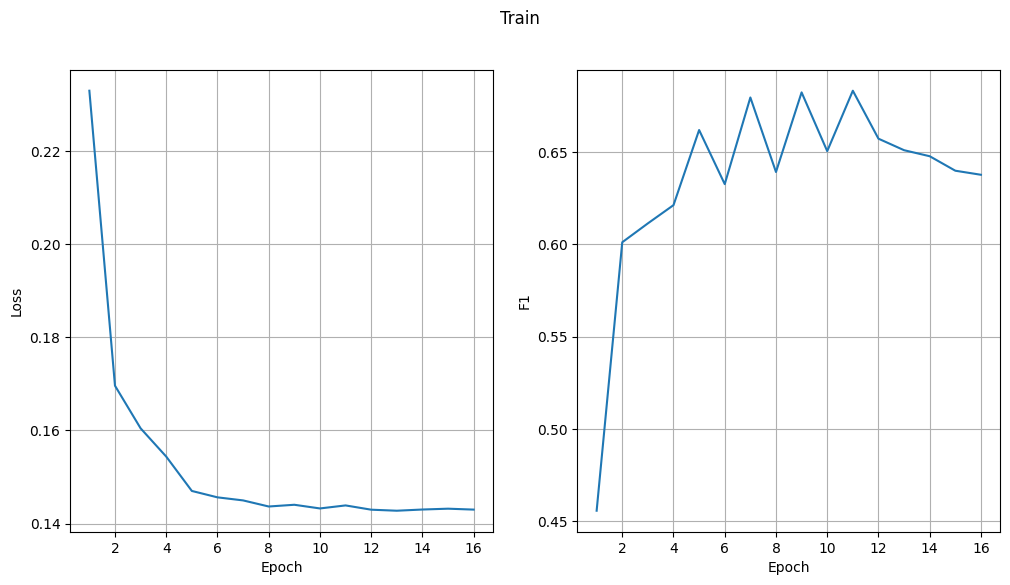

In [ ]:
fig, axes = plt.subplots(nrows=1, ncols=2, figsize=(12, 6))
axes[0].plot(np.arange(1, num_epochs+1), history["train_loss"])
axes[0].set_xlabel("Epoch")
axes[0].set_ylabel("Loss")
axes[0].grid()
fig.suptitle("Train")
axes[1].plot(np.arange(1, num_epochs+1), history["train_f1"])
axes[1].set_xlabel("Epoch")
axes[1].set_ylabel("F1")
axes[1].grid()
plt.show()

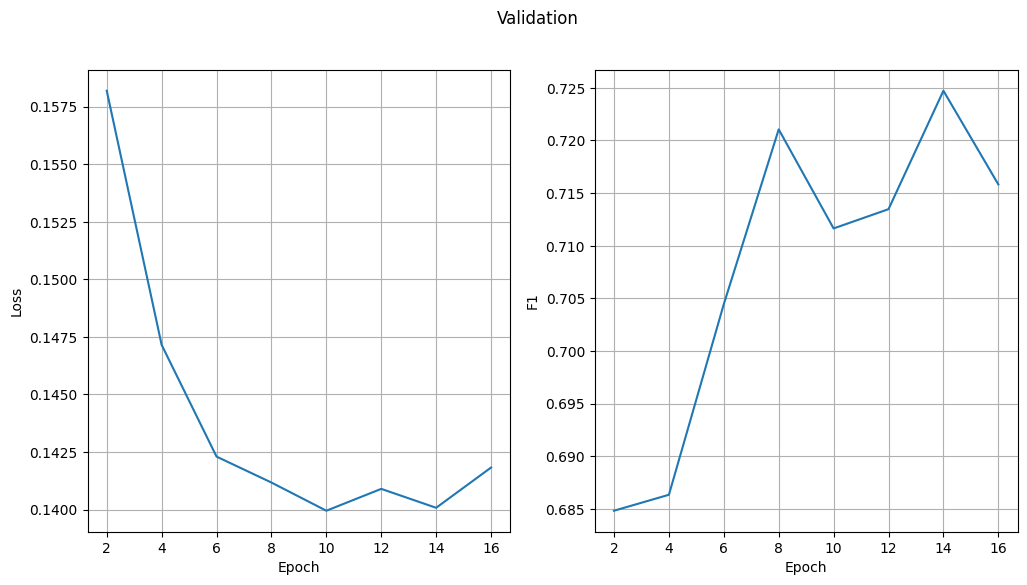

In [ ]:
fig, axes = plt.subplots(nrows=1, ncols=2, figsize=(12, 6))
axes[0].plot(np.arange(2, num_epochs+1, 2), history["val_loss"])
axes[0].set_xlabel("Epoch")
axes[0].set_ylabel("Loss")
axes[0].grid()
fig.suptitle("Validation")
axes[1].plot(np.arange(2, num_epochs+1, 2), history["val_f1"])
axes[1].set_xlabel("Epoch")
axes[1].set_ylabel("F1")
axes[1].grid()
plt.show()

In [9]:
loaded_model = mlflow.pytorch.load_model(f"models:/{registered_model_name}@logbert_065")

Создаем занаво валидационные датасеты с флагом predict_mode=True, чтобы приходили незамаскированные последовательности. Во время предсказания эти последовательности будут несколько раз маскироваться, чтобы усилить прогноз и избежать случайности

In [13]:
val_normal_dataset = LogBERTDataset(vocab=vocab, sequences=val_normal_log_sequences, seq_len=512, mask_ratio=mask_ratio, predict_mode=True)
val_abnormal_dataset = LogBERTDataset(vocab=vocab, sequences=val_abnormal_log_sequences, seq_len=512, mask_ratio=mask_ratio, predict_mode=True)

val_normal_dataloader = DataLoader(val_normal_dataset, batch_size=64, shuffle=False, num_workers=2, collate_fn=val_normal_dataset.collate_fn)
val_abnormal_dataloader = DataLoader(val_abnormal_dataset, batch_size=64, shuffle=False, num_workers=2, collate_fn=val_abnormal_dataset.collate_fn)

In [23]:
test_predictor = Predictor(loaded_model, val_normal_dataloader, test_abnormal_dataloader, device, vocab["PAD"], vocab["MASK"], 3, 0.65)

In [15]:
test_predictor.predict()


############################################################

Testing normal predicting

############################################################
Batch 10/873
Batch 20/873
Batch 30/873
Batch 40/873
Batch 50/873
Batch 60/873
Batch 70/873
Batch 80/873
Batch 90/873
Batch 100/873
Batch 110/873
Batch 120/873
Batch 130/873
Batch 140/873
Batch 150/873
Batch 160/873
Batch 170/873
Batch 180/873
Batch 190/873
Batch 200/873
Batch 210/873
Batch 220/873
Batch 230/873
Batch 240/873
Batch 250/873
Batch 260/873
Batch 270/873
Batch 280/873
Batch 290/873
Batch 300/873
Batch 310/873
Batch 320/873
Batch 330/873
Batch 340/873
Batch 350/873
Batch 360/873
Batch 370/873
Batch 380/873
Batch 390/873
Batch 400/873
Batch 410/873
Batch 420/873
Batch 430/873
Batch 440/873
Batch 450/873
Batch 460/873
Batch 470/873
Batch 480/873
Batch 490/873
Batch 500/873
Batch 510/873
Batch 520/873
Batch 530/873
Batch 540/873
Batch 550/873
Batch 560/873
Batch 570/873
Batch 580/873
Batch 590/873
Batch 600/873
Batch 610/873
Batc

В данном случае смотрим только на вывод соответствующего порога, дабы не писать новый метод для предсказания теста

In [24]:
predictor = Predictor(loaded_model, test_normal_dataloader, test_abnormal_dataloader, device, vocab["PAD"], vocab["MASK"], 3, 0.65)

In [25]:
predictor.predict()


############################################################

Testing normal predicting

############################################################
Batch 10/873
Batch 20/873
Batch 30/873
Batch 40/873
Batch 50/873
Batch 60/873
Batch 70/873
Batch 80/873
Batch 90/873
Batch 100/873
Batch 110/873
Batch 120/873
Batch 130/873
Batch 140/873
Batch 150/873
Batch 160/873
Batch 170/873
Batch 180/873
Batch 190/873
Batch 200/873
Batch 210/873
Batch 220/873
Batch 230/873
Batch 240/873
Batch 250/873
Batch 260/873
Batch 270/873
Batch 280/873
Batch 290/873
Batch 300/873
Batch 310/873
Batch 320/873
Batch 330/873
Batch 340/873
Batch 350/873
Batch 360/873
Batch 370/873
Batch 380/873
Batch 390/873
Batch 400/873
Batch 410/873
Batch 420/873
Batch 430/873
Batch 440/873
Batch 450/873
Batch 460/873
Batch 470/873
Batch 480/873
Batch 490/873
Batch 500/873
Batch 510/873
Batch 520/873
Batch 530/873
Batch 540/873
Batch 550/873
Batch 560/873
Batch 570/873
Batch 580/873
Batch 590/873
Batch 600/873
Batch 610/873
Batc